# Injury flags + backend metrics

This notebook:
- parses `data/raw/injury.txt` (injury events + recovery windows)
- computes the same daily metrics and workload features as the backend
- compares condition prediction with and without injury flags

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from datetime import datetime, timedelta

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

pd.set_option("display.max_columns", 200)

CSV_PATH = Path("/workspace/data/raw/StatsAllGroup.csv")
INJURY_PATH = Path("/workspace/data/raw/injury.txt")

DEFAULT_RECOVERY_DAYS = 28  # used when recovery length is missing
RECOVERY_RANGE_STRATEGY = "max"  # "max" | "min" | "mean"

In [2]:
# --- CSV + aggregation helpers (aligned with backend/api/services.py) ---

ACWR_ALPHA_ACUTE = 2 / (7 + 1)
ACWR_ALPHA_CHRONIC = 2 / (28 + 1)
ACWR_FLOOR = 1e-3
ACWR_BASELINE_FLOOR_RATIO = 0.3
MONOTONY_WINDOW = 7
EPS = 1e-6
MIN_DIST_FOR_DECEL_DENSITY = 100  # meters
MIN_DIST_FOR_MECH_EFF = 500       # meters


def detect_csv_encoding(csv_path: Path, sample_size: int = 1024 * 256) -> str:
    with csv_path.open("rb") as handle:
        sample = handle.read(sample_size)

    encodings = [
        "utf-8-sig",
        "utf-8",
        "cp932",
        "shift_jis",
        "euc_jp",
        "latin-1",
    ]

    last_error = None
    for enc in encodings:
        try:
            sample.decode(enc, errors="strict")
            return enc
        except Exception as exc:
            last_error = exc
            continue

    raise RuntimeError(f"Failed to detect CSV encoding. last_error={last_error}")


def _resolve_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _coerce_numeric(df: pd.DataFrame, columns: list[str]) -> None:
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")


def _collect_sum_columns(df: pd.DataFrame) -> list[str]:
    base_cols = [
        "total_duration",
        "total_distance",
        "total_player_load",
        "total_dive_count",
        "dive_right_count",
        "dive_left_count",
        "dive_centre_count",
        "total_dive_load",
        "total_dive_load_left",
        "total_dive_load_right",
        "total_dive_load_centre",
        "total_jumps",
        "high_decel_count",
        "ima_band3_decel_count",
        "total_time_to_feet",
    ]
    velocity_cols = [f"velocity_band{i}_total_distance" for i in range(1, 7)]
    dynamic_cols = []
    for col in df.columns:
        if col.startswith("ima_band2_") or col.startswith("ima_band3_"):
            dynamic_cols.append(col)
        elif col.startswith("total_time_to_feet_"):
            dynamic_cols.append(col)

    cols = []
    seen = set()
    for col in base_cols + velocity_cols + dynamic_cols:
        if col in df.columns and col not in seen:
            cols.append(col)
            seen.add(col)
    return cols


def _collect_aggregation_columns(df: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    sum_cols = _collect_sum_columns(df)
    max_cols = [col for col in ["max_vel", "Max Velocity"] if col in df.columns]
    mean_cols = [col for col in ["mean_heart_rate", "Avg HR"] if col in df.columns]
    return sum_cols, max_cols, mean_cols


def load_statsallgroup_dataframe(csv_path: Path) -> tuple[pd.DataFrame, str, list[str], list[str], list[str]]:
    encoding = detect_csv_encoding(csv_path)
    df = pd.read_csv(csv_path, encoding=encoding, dtype=str)
    df.columns = [str(col).strip() for col in df.columns]

    athlete_id_col = _resolve_column(df, ["athlete_id", "AthleteID", "player_id"])
    if not athlete_id_col:
        raise RuntimeError("Missing athlete_id column.")
    df["athlete_id"] = df[athlete_id_col].astype(str).str.strip().replace({"nan": ""})

    athlete_name_col = _resolve_column(df, ["athlete_name", "AthleteName", "player_name"])
    if athlete_name_col:
        df["athlete_name"] = df[athlete_name_col].astype(str).str.strip().replace({"nan": ""})
    else:
        df["athlete_name"] = ""

    date_col = _resolve_column(df, ["date_", "date", "Date", "session_date"])
    if not date_col:
        raise RuntimeError("Missing date column.")
    df["date_"] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()

    df = df[df["athlete_id"] != ""]
    df = df[df["date_"].notna()]

    sum_cols, max_cols, mean_cols = _collect_aggregation_columns(df)
    numeric_cols = list(set(sum_cols + max_cols + mean_cols))
    _coerce_numeric(df, numeric_cols)

    return df, encoding, sum_cols, max_cols, mean_cols


def _first_non_empty(values) -> str:
    for value in values:
        if value is None:
            continue
        text = str(value).strip()
        if text and text.lower() != "nan":
            return text
    return ""


def aggregate_daily(
    df: pd.DataFrame,
    sum_cols: list[str],
    max_cols: list[str],
    mean_cols: list[str],
) -> pd.DataFrame:
    agg_map = {col: "sum" for col in sum_cols}
    agg_map.update({col: "max" for col in max_cols})
    agg_map.update({col: "mean" for col in mean_cols})

    group_cols = ["athlete_id", "date_"]
    name_df = (
        df.groupby(group_cols, dropna=False)["athlete_name"]
        .agg(_first_non_empty)
        .reset_index()
    )
    if not agg_map:
        agg_df = df[group_cols].drop_duplicates().reset_index(drop=True)
    else:
        agg_df = df.groupby(group_cols, dropna=False).agg(agg_map).reset_index()
    return agg_df.merge(name_df, on=group_cols, how="left")


def zero_pad_daily(df_daily: pd.DataFrame, sum_cols: list[str]) -> pd.DataFrame:
    if df_daily.empty:
        return df_daily

    min_date = df_daily["date_"].min()
    max_date = df_daily["date_"].max()
    all_dates = pd.DataFrame({"date_": pd.date_range(min_date, max_date, freq="D")})
    athletes = (
        df_daily.groupby("athlete_id", as_index=False)["athlete_name"]
        .agg(_first_non_empty)
    )

    base = all_dates.assign(key=1).merge(athletes.assign(key=1), on="key").drop("key", axis=1)
    daily_payload = df_daily.drop(columns=["athlete_name"], errors="ignore")
    merged = base.merge(
        daily_payload,
        on=["date_", "athlete_id"],
        how="left",
    )

    for col in sum_cols:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)

    return merged


def determine_positions(
    df_daily: pd.DataFrame,
    *,
    dive_threshold: float = 50,
    daily_dive_threshold: float = 3,
) -> tuple[pd.DataFrame, dict[str, str]]:
    df_daily = df_daily.copy()
    dive_cols = ["dive_right_count", "dive_left_count", "dive_centre_count"]
    for col in dive_cols:
        if col not in df_daily.columns:
            df_daily[col] = 0

    total_dives = df_daily[dive_cols].sum(axis=1)
    totals = total_dives.groupby(df_daily["athlete_id"]).sum()
    daily_max = total_dives.groupby(df_daily["athlete_id"]).max()

    positions = {}
    for athlete_id in df_daily["athlete_id"].dropna().unique():
        total = totals.get(athlete_id, 0)
        day_max = daily_max.get(athlete_id, 0)
        if total >= dive_threshold or day_max > daily_dive_threshold:
            positions[athlete_id] = "GK"
        else:
            positions[athlete_id] = "FP"

    df_daily["position"] = df_daily["athlete_id"].map(positions).fillna("FP")
    return df_daily, positions


def build_gps_daily(
    df_daily: pd.DataFrame,
    sum_cols: list[str],
    max_cols: list[str],
    mean_cols: list[str],
) -> pd.DataFrame:
    df = df_daily.copy()

    metric_cols = [col for col in (sum_cols + max_cols + mean_cols) if col in df.columns]

    if "max_vel" not in df.columns and "Max Velocity" in df.columns:
        df["max_vel"] = df["Max Velocity"]
    if "mean_heart_rate" not in df.columns and "Avg HR" in df.columns:
        df["mean_heart_rate"] = df["Avg HR"]

    def col_or_zero(col: str):
        if col in df.columns:
            return df[col]
        return pd.Series(0, index=df.index)

    df["total_duration"] = col_or_zero("total_duration").fillna(0).astype(float)
    df["total_distance"] = col_or_zero("total_distance").fillna(0).astype(float)
    df["total_player_load"] = col_or_zero("total_player_load").fillna(0).astype(float)
    df["total_jumps"] = col_or_zero("total_jumps").fillna(0).astype(float)
    df["max_vel"] = col_or_zero("max_vel").fillna(0).astype(float)
    df["mean_heart_rate"] = col_or_zero("mean_heart_rate")

    band5 = col_or_zero("velocity_band5_total_distance").fillna(0).astype(float)
    band6 = col_or_zero("velocity_band6_total_distance").fillna(0).astype(float)
    df["hsr_distance"] = band5 + band6

    high_decel = col_or_zero("high_decel_count")
    if "high_decel_count" not in df.columns:
        high_decel = col_or_zero("ima_band2_decel_count") + col_or_zero("ima_band3_decel_count")
    df["high_decel_count"] = high_decel.fillna(0).astype(float)

    if "total_dive_count" in df.columns:
        total_dive = col_or_zero("total_dive_count")
    else:
        total_dive = col_or_zero("dive_left_count") + col_or_zero("dive_right_count") + col_or_zero("dive_centre_count")
    df["total_dive_count"] = total_dive.fillna(0).astype(float)

    total_time_to_feet = col_or_zero("total_time_to_feet").fillna(0).astype(float)
    for col in df.columns:
        if col.startswith("total_time_to_feet_"):
            total_time_to_feet = total_time_to_feet + col_or_zero(col).fillna(0).astype(float)

    df["avg_time_to_feet"] = np.where(
        df["total_dive_count"] > 0,
        total_time_to_feet / df["total_dive_count"].replace(0, np.nan),
        np.nan,
    )

    df["metrics"] = df[metric_cols].apply(lambda row: row.to_dict(), axis=1)
    df["date"] = df["date_"]

    return df

In [3]:
# --- Injury parsing helpers ---

def normalize_digits(text: str) -> str:
    if not text:
        return text
    trans = str.maketrans("０１２３４５６７８９", "0123456789")
    return text.translate(trans)

def normalize_jp_name(name: str) -> str:
    if not name:
        return ""
    name = name.replace(" ", "").replace("　", "")
    return name.strip()

def parse_jp_date(text: str):
    if not text:
        return None
    text = normalize_digits(text)
    m = re.search(r"(\d{4})年\s*(\d{1,2})月\s*(\d{1,2})日", text)
    if not m:
        return None
    y, mo, d = map(int, m.groups())
    try:
        return datetime(y, mo, d).date()
    except ValueError:
        return None

def parse_recovery_days(text: str, strategy: str = "max") -> int | None:
    if not text:
        return None
    text = normalize_digits(text)
    # range like "8〜10週"
    range_match = re.search(r"(\d+)\s*[\-〜～~]\s*(\d+)\s*(週|週間|ヶ月|か月|月)", text)
    if range_match:
        a, b, unit = range_match.groups()
        lo, hi = int(a), int(b)
        if strategy == "min":
            val = lo
        elif strategy == "mean":
            val = int(round((lo + hi) / 2))
        else:
            val = hi
        return val * (7 if "週" in unit else 30)

    m = re.search(r"(\d+)\s*(週|週間)", text)
    if m:
        return int(m.group(1)) * 7

    m = re.search(r"(\d+)\s*(ヶ月|か月|月)", text)
    if m:
        return int(m.group(1)) * 30

    return None

def parse_injury_text(path: Path) -> pd.DataFrame:
    raw = path.read_text(encoding="utf-8", errors="replace")
    lines = raw.splitlines()
    blocks = []
    current = []
    for line in lines:
        if "負傷のお知らせ" in line and current:
            blocks.append("\n".join(current).strip())
            current = []
        if not line.strip() and not current:
            continue
        current.append(line)
    if current:
        blocks.append("\n".join(current).strip())

    rows = []
    for block in blocks:
        name_match = re.search(r"^(.+?)選手", block, flags=re.M)
        name_jp = name_match.group(1).strip() if name_match else ""
        name_jp_norm = normalize_jp_name(name_jp)

        injury_line = None
        m = re.search(r"受傷日\s*\n([^\n]+)", block)
        if m:
            injury_line = m.group(1)
        else:
            m = re.search(r"手術日\s*\n([^\n]+)", block)
            if m:
                injury_line = m.group(1)

        injury_date = parse_jp_date(injury_line or "")

        recovery_days = None
        m = re.search(r"全治\s*\n([^\n]+)", block)
        if m:
            recovery_days = parse_recovery_days(m.group(1), strategy=RECOVERY_RANGE_STRATEGY)
        else:
            # sometimes recovery is on the same line as 全治
            m = re.search(r"全治[^\n]*", block)
            if m:
                recovery_days = parse_recovery_days(m.group(0), strategy=RECOVERY_RANGE_STRATEGY)

        rows.append(
            {
                "name_jp": name_jp,
                "name_jp_norm": name_jp_norm,
                "injury_date": injury_date,
                "recovery_days": recovery_days,
                "raw_block": block,
            }
        )

    return pd.DataFrame(rows)

JP_TO_EN = {
    "若谷拓海": ["Takumi WAKAYA"],
    "平山駿": ["Shun HIRAYAMA"],
    "吉丸絢梓": ["Kenshin YOSHIMARU"],
    "前田紘基": ["Hiroki MAEDA"],
    "上形洋介": ["Yosuke KAMIGATA"],
    "夛田凌輔": ["Ryosuke TADA"],
    "矢田旭": ["Asahi YADA", "Asai YADA"],
    "坂本翔": ["Kakeru SAKAMOTO", "Kakeru Sakamoto"],
    "田中悠也": ["Yuya TANAKA"],
    "谷口璃成": ["Ryusei TANIGUCHI"],
    "世良務": ["Tsukasa SERA"],
    "永井龍": ["Ryu NAGAI", "Ryo NAGAI"],
    "平原隆暉": ["Ryuki HIRAHARA"],
}

def normalize_en_name(name: str) -> str:
    if not name:
        return ""
    return re.sub(r"\s+", " ", name.strip()).upper()

def map_injuries_to_en(df_inj: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df_inj.iterrows():
        name_jp_norm = row.get("name_jp_norm", "")
        mapped = JP_TO_EN.get(name_jp_norm)
        if not mapped:
            rows.append({**row, "athlete_name": None})
            continue
        for en_name in mapped:
            rows.append({**row, "athlete_name": en_name})
    out = pd.DataFrame(rows)
    out["athlete_name_norm"] = out["athlete_name"].apply(normalize_en_name)
    return out


In [4]:
# --- Workload feature computation (aligned with backend/api/services.py) ---

def to_float(value):
    if value is None:
        return 0.0
    try:
        val = float(value)
    except (TypeError, ValueError):
        return 0.0
    if np.isnan(val):
        return 0.0
    return val


def safe_number(value: float | int | None):
    if value is None:
        return None
    try:
        v = float(value)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None


def calc_acwr_ewma(series, alpha_fast=ACWR_ALPHA_ACUTE, alpha_slow=ACWR_ALPHA_CHRONIC):
    acute = series.ewm(alpha=alpha_fast, adjust=False).mean()
    chronic_raw = series.ewm(alpha=alpha_slow, adjust=False).mean()
    baseline = series.mean()
    floor = max(baseline * ACWR_BASELINE_FLOOR_RATIO, ACWR_FLOOR)
    chronic = np.maximum(chronic_raw, floor)
    ratio = acute / chronic
    return acute.values, chronic.values, ratio.values


def calc_monotony_series(series, window=MONOTONY_WINDOW):
    r_mean = series.rolling(window=window, min_periods=1).mean()
    r_std = series.rolling(window=window, min_periods=1).std().fillna(0)
    denom = np.maximum(r_std, EPS)
    return (r_mean / denom).fillna(0).values


def calc_asymmetry_series(left, right):
    left_arr = np.array(left, dtype=float)
    right_arr = np.array(right, dtype=float)
    return np.abs(left_arr - right_arr) / np.maximum(left_arr + right_arr, EPS)


def classify_fp(
    acwr_load: float | None,
    acwr_hsr: float | None,
    acwr_ima_decel: float | None,
    monotony: float | None,
    efficiency: float | None = None,
) -> tuple[str, list[str]]:
    reasons = []
    level = "safety"

    # Condition (heart rate efficiency)
    if efficiency and efficiency < 0.8:
        level = "risky"
        reasons.append(f"Efficiency Low ({efficiency:.2f})")
    elif efficiency and efficiency < 1.0:
        if level == "safety":
            level = "caution"
        reasons.append(f"Efficiency Slightly Low ({efficiency:.2f})")

    # Injury risk (ACWR)
    if acwr_load and acwr_load > 1.5:
        level = "risky"
        reasons.append(f"Load ACWR High ({acwr_load:.2f})")
    elif acwr_load and acwr_load > 1.3:
        if level == "safety":
            level = "caution"
        reasons.append(f"Load ACWR Elevated ({acwr_load:.2f})")

    if acwr_hsr and acwr_hsr > 1.5:
        level = "risky"
        reasons.append(f"HSR ACWR High ({acwr_hsr:.2f})")
    elif acwr_hsr and acwr_hsr > 1.3:
        if level == "safety":
            level = "caution"
        reasons.append(f"HSR ACWR Elevated ({acwr_hsr:.2f})")

    # Decel ACWR
    if acwr_ima_decel and acwr_ima_decel > 1.5:
        level = "risky"
        reasons.append(f"Decel ACWR High ({acwr_ima_decel:.2f})")
    elif acwr_ima_decel and acwr_ima_decel > 1.3:
        if level == "safety":
            level = "caution"
        reasons.append(f"Decel ACWR Elevated ({acwr_ima_decel:.2f})")

    # Monotony
    if monotony and monotony > 2.5:
        if level == "safety":
            level = "caution"
        reasons.append(f"High Monotony ({monotony:.2f})")

    return level, reasons


def classify_gk(
    acwr_dive: float | None,
    asymmetry: float | None,
    monotony: float | None,
    time_to_feet: float | None = None,
) -> tuple[str, list[str]]:
    reasons = []
    level = "safety"

    if time_to_feet and time_to_feet > 2.0:
        level = "risky"
        reasons.append(f"Slow Recovery Time ({time_to_feet:.2f}s)")
    elif time_to_feet and time_to_feet > 1.5:
        if level == "safety":
            level = "caution"
        reasons.append(f"Recovery Time Elevated ({time_to_feet:.2f}s)")

    if acwr_dive and acwr_dive > 1.5:
        level = "risky"
        reasons.append(f"Dive ACWR High ({acwr_dive:.2f})")

    if asymmetry and asymmetry > 0.4:
        if level == "safety":
            level = "caution"
        reasons.append(f"High Asymmetry ({asymmetry:.2f})")

    if monotony and monotony > 2.5:
        if level == "safety":
            level = "caution"
        reasons.append(f"High Monotony ({monotony:.2f})")

    return level, reasons


def build_workload_features(df_gps: pd.DataFrame, positions: dict[str, str]) -> pd.DataFrame:
    if df_gps.empty:
        return df_gps

    out_rows = []

    for athlete_id, group in df_gps.groupby("athlete_id"):
        group = group.sort_values("date")

        full_idx = pd.date_range(
            start=group["date"].min(), end=group["date"].max(), freq="D"
        )
        group = (
            group.set_index("date")
            .reindex(full_idx, fill_value=0)
            .reset_index()
            .rename(columns={"index": "date"})
        )
        group["metrics"] = group["metrics"].apply(lambda m: m if isinstance(m, dict) else {})

        is_gk = positions.get(athlete_id, "FP") == "GK"

        total_distance = group["total_distance"].fillna(0).astype(float)
        total_player_load = group["total_player_load"].fillna(0).astype(float)
        hsr_distance = group["hsr_distance"].fillna(0).astype(float)
        total_dive_count = group["total_dive_count"].fillna(0).astype(float)
        avg_time_to_feet = group["avg_time_to_feet"].astype(float)
        mean_heart_rate = group["mean_heart_rate"].astype(float)
        high_decel_count = group["high_decel_count"].fillna(0).astype(float)
        total_jumps = group["total_jumps"].fillna(0).astype(float)

        metrics_series = group["metrics"].apply(lambda m: m or {})
        decel_count = high_decel_count
        ima_left = metrics_series.apply(lambda m: to_float(m.get("ima_band2_left_count")))
        ima_right = metrics_series.apply(lambda m: to_float(m.get("ima_band2_right_count")))
        high_ima_decel = metrics_series.apply(lambda m: to_float(m.get("ima_band3_decel_count")))
        high_metabolic_dist = metrics_series.apply(
            lambda m: (
                to_float(m.get("metabolic_power_band4_total_distance"))
                + to_float(m.get("metabolic_power_band5_total_distance"))
                + to_float(m.get("metabolic_power_band6_total_distance"))
            )
        )
        dive_left = metrics_series.apply(lambda m: to_float(m.get("dive_left_count")))
        dive_right = metrics_series.apply(lambda m: to_float(m.get("dive_right_count")))
        dive_centre = metrics_series.apply(lambda m: to_float(m.get("dive_centre_count")))

        _, _, acwr_load = calc_acwr_ewma(total_player_load)
        monotony = calc_monotony_series(total_player_load)

        acwr_hsr = np.full(len(group), np.nan)
        acwr_dive = np.full(len(group), np.nan)
        acwr_ima_decel = np.full(len(group), np.nan)
        asym_val = np.zeros(len(group))
        decel_density = np.zeros(len(group))
        load_per_meter = np.zeros(len(group))
        efficiency = np.full(len(group), np.nan)
        metabolic_ratio = np.full(len(group), np.nan)

        dist_safe = np.maximum(total_distance.values, EPS)
        dist_km = dist_safe / 1000.0
        decel_density = np.where(dist_safe < MIN_DIST_FOR_DECEL_DENSITY, 0.0, decel_count.values / np.maximum(dist_km, EPS))
        load_per_meter = np.where(
            dist_safe < MIN_DIST_FOR_MECH_EFF, np.nan, total_player_load.values / dist_safe
        )
        efficiency = np.where(
            mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
        )
        _, _, acwr_ima_decel = calc_acwr_ewma(high_ima_decel.astype(float))
        metabolic_ratio = np.where(
            total_distance.values > 0,
            high_metabolic_dist.values / dist_safe,
            np.nan,
        )

        if is_gk:
            _, _, acwr_dive = calc_acwr_ewma(total_dive_count)
            total_dives = dive_left + dive_right + dive_centre
            asym_val = calc_asymmetry_series(dive_left, dive_right)
            asym_val = np.where(total_dives.values <= 0, 0.0, asym_val)
        else:
            _, _, acwr_hsr = calc_acwr_ewma(hsr_distance)
            asym_val = calc_asymmetry_series(ima_left, ima_right)
            acwr_dive = np.full(len(group), np.nan)

        for i, row in group.iterrows():
            acwr_load_v = safe_number(acwr_load[i])
            acwr_hsr_v = safe_number(acwr_hsr[i])
            acwr_dive_v = safe_number(acwr_dive[i])
            acwr_ima_decel_v = safe_number(acwr_ima_decel[i])
            monotony_v = safe_number(monotony[i])
            asym_v = safe_number(asym_val[i])
            lpm_v = safe_number(load_per_meter[i])
            decel_density_v = safe_number(decel_density[i])
            efficiency_v = safe_number(efficiency[i])
            metabolic_ratio_v = safe_number(metabolic_ratio[i])
            high_metabolic_dist_v = safe_number(high_metabolic_dist.iat[i])
            time_to_feet_v = safe_number(avg_time_to_feet.iat[i])

            if is_gk:
                risk_level, risk_reasons = classify_gk(
                    acwr_dive_v,
                    asym_v,
                    monotony_v,
                    time_to_feet=time_to_feet_v,
                )
            else:
                risk_level, risk_reasons = classify_fp(
                    acwr_load_v,
                    acwr_hsr_v,
                    acwr_ima_decel_v,
                    monotony_v,
                    efficiency=efficiency_v,
                )

            out_rows.append(
                {
                    "athlete_id": athlete_id,
                    "date": row["date"],
                    "total_duration": safe_number(row.get("total_duration")),
                    "total_distance": safe_number(row.get("total_distance")),
                    "total_player_load": safe_number(row.get("total_player_load")),
                    "max_vel": safe_number(row.get("max_vel")),
                    "mean_heart_rate": safe_number(row.get("mean_heart_rate")),
                    "hsr_distance": safe_number(row.get("hsr_distance")),
                    "high_decel_count": safe_number(row.get("high_decel_count")),
                    "total_dive_count": safe_number(row.get("total_dive_count")),
                    "avg_time_to_feet": safe_number(row.get("avg_time_to_feet")),
                    "total_jumps": safe_number(row.get("total_jumps")),
                    "acwr_load": acwr_load_v,
                    "acwr_hsr": acwr_hsr_v,
                    "acwr_dive": acwr_dive_v,
                    "efficiency_index": efficiency_v,
                    "monotony_load": monotony_v,
                    "load_per_meter": lpm_v,
                    "risk_level": risk_level,
                    "risk_reasons": risk_reasons,
                    "val_asymmetry": asym_v,
                    "decel_density": decel_density_v,
                    "time_to_feet": time_to_feet_v,
                    "acwr_ima_decel": acwr_ima_decel_v,
                    "metabolic_ratio": metabolic_ratio_v,
                    "high_metabolic_dist": high_metabolic_dist_v,
                }
            )

    return pd.DataFrame(out_rows)

In [5]:
# --- Load CSV and build daily + workload features ---

df_raw, encoding, sum_cols, max_cols, mean_cols = load_statsallgroup_dataframe(CSV_PATH)
print("encoding:", encoding)
print("raw rows:", len(df_raw))

# daily aggregation
_df_daily = aggregate_daily(df_raw, sum_cols, max_cols, mean_cols)
_df_daily = zero_pad_daily(_df_daily, sum_cols)
_df_daily, positions = determine_positions(_df_daily)

# gps daily metrics
_df_gps = build_gps_daily(_df_daily, sum_cols, max_cols, mean_cols)

# workload features (backend-aligned)
features_df = build_workload_features(_df_gps, positions)

# attach athlete_name
name_map = _df_gps.groupby("athlete_id")["athlete_name"].first().to_dict()
features_df["athlete_name"] = features_df["athlete_id"].map(name_map)
features_df["athlete_name_norm"] = features_df["athlete_name"].apply(normalize_en_name)

print("features rows:", len(features_df))
features_df.head()

/tmp/ipykernel_59097/2351084014.py:112: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date_"] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()


encoding: cp932
raw rows: 68172


/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  mean_heart_rate.values > 0, total_player_load.values / mean_heart_rate.values, np.nan
/tmp/ipykernel_59097/1135241797.py:202: RuntimeWarning: divide by zero encountered in divide
  

features rows: 69860


,athlete_id,date,total_duration,total_distance,total_player_load,max_vel,mean_heart_rate,hsr_distance,high_decel_count,total_dive_count,avg_time_to_feet,total_jumps,acwr_load,acwr_hsr,acwr_dive,efficiency_index,monotony_load,load_per_meter,risk_level,risk_reasons,val_asymmetry,decel_density,time_to_feet,acwr_ima_decel,metabolic_ratio,high_metabolic_dist,athlete_name,athlete_name_norm
0,09bb407a-a555-496a-957d-25a97ccb1519,2023-01-12,8089.00,7098.09463,780.32599,23.67537,152.528436,289.57001,10.0,3.0,2.633333,19.0,1.000000,NaN,1.000000,5.115938,7.803260e+08,0.109935,risky,"[Slow Recovery Time (2.63s), High Asymmetry (1...",1.000000,1.408829,2.633333,1.000000,0.0,0.0,Daiki GOTO,DAIKI GOTO
1,09bb407a-a555-496a-957d-25a97ccb1519,2023-01-13,5266.00,4990.87757,539.11669,25.75216,147.497320,248.66000,7.0,37.0,1.229730,27.0,0.942821,NaN,2.151613,3.655095,3.867956e+00,0.108020,risky,"[Dive ACWR High (2.15), High Monotony (3.87)]",0.027027,1.402559,1.229730,0.938235,0.0,0.0,Daiki GOTO,DAIKI GOTO
2,09bb407a-a555-496a-957d-25a97ccb1519,2023-01-14,6857.00,6647.65204,757.02278,25.94725,146.655444,127.27000,15.0,42.0,1.121429,55.0,0.955508,NaN,2.429259,5.161914,5.202360e+00,0.113878,risky,"[Dive ACWR High (2.43), High Monotony (5.20)]",0.130435,2.256436,1.121429,0.826525,0.0,0.0,Daiki GOTO,DAIKI GOTO
3,09bb407a-a555-496a-957d-25a97ccb1519,2023-01-15,0.00,0.00000,0.00000,0.00000,NaN,0.00000,0.0,0.0,NaN,0.0,0.769715,NaN,1.956903,NaN,1.431151e+00,NaN,risky,[Dive ACWR High (1.96)],0.000000,0.000000,NaN,0.665812,NaN,0.0,Daiki GOTO,DAIKI GOTO
4,09bb407a-a555-496a-957d-25a97ccb1519,2023-01-16,6953.97,5970.34784,751.75157,21.54934,141.201090,3.83000,48.0,65.0,1.356923,49.0,0.838417,NaN,2.388576,5.323979,1.709355e+00,0.125914,risky,[Dive ACWR High (2.39)],0.111111,8.039733,1.356923,0.986521,0.0,0.0,Daiki GOTO,DAIKI GOTO


In [6]:
# --- Parse injury.txt and add flags ---

def add_injury_flags(df: pd.DataFrame, injuries: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ["injury_event", "injury_window", "injury_recent_7d", "injury_recent_14d", "injury_recent_28d"]:
        out[col] = 0

    for _, row in injuries.iterrows():
        name_norm = row.get("athlete_name_norm")
        injury_date = row.get("injury_date")
        if not name_norm or not injury_date:
            continue

        rec_days = row.get("recovery_days")
        if pd.isna(rec_days):
            rec_days = DEFAULT_RECOVERY_DAYS

        mask = out["athlete_name_norm"] == name_norm
        if not mask.any():
            continue

        injury_dt = pd.to_datetime(injury_date)

        out.loc[mask & (out["date"].dt.normalize() == injury_dt), "injury_event"] = 1
        out.loc[
            mask
            & (out["date"] >= injury_dt)
            & (out["date"] <= injury_dt + pd.Timedelta(days=int(rec_days))),
            "injury_window",
        ] = 1

        for days, col in [(7, "injury_recent_7d"), (14, "injury_recent_14d"), (28, "injury_recent_28d")]:
            out.loc[
                mask
                & (out["date"] >= injury_dt)
                & (out["date"] <= injury_dt + pd.Timedelta(days=days)),
                col,
            ] = 1

    return out

injuries_raw = parse_injury_text(INJURY_PATH)
injuries_mapped = map_injuries_to_en(injuries_raw)

unmatched = injuries_mapped[injuries_mapped["athlete_name"].isna()]["name_jp"].unique()
print("unmatched jp names:", unmatched)

injuries_used = injuries_mapped[injuries_mapped["athlete_name"].notna()].copy()
print("injury rows:", len(injuries_used))

features_df = add_injury_flags(features_df, injuries_used)
features_df[["athlete_name", "date", "injury_event", "injury_window", "injury_recent_7d"]].head()

unmatched jp names: []
injury rows: 17


,athlete_name,date,injury_event,injury_window,injury_recent_7d
0,Daiki GOTO,2023-01-12,0,0,0
1,Daiki GOTO,2023-01-13,0,0,0
2,Daiki GOTO,2023-01-14,0,0,0
3,Daiki GOTO,2023-01-15,0,0,0
4,Daiki GOTO,2023-01-16,0,0,0


In [7]:
# --- Risk level v2 (relative thresholds) + next-day display (2-day validity) ---
def add_rolling_quantile(df, col, q, window=28, min_periods=7):
    return (
        df.groupby("athlete_id")[col]
        .rolling(window, min_periods=min_periods)
        .quantile(q)
        .reset_index(level=0, drop=True)
    )

df_v2 = features_df.sort_values(["athlete_id", "date"]).copy()
if "position" not in df_v2.columns:
    if "positions" in globals():
        df_v2["position"] = df_v2["athlete_id"].map(positions).fillna("FP")
    else:
        df_v2["position"] = "FP"

# training day filter
df_v2["is_training_day"] = (df_v2["total_duration"].fillna(0) > 0) | (df_v2["total_distance"].fillna(0) > 0)

# rolling quantiles (per athlete)
df_v2["p10_eff"] = add_rolling_quantile(df_v2, "efficiency_index", 0.10)
df_v2["p25_eff"] = add_rolling_quantile(df_v2, "efficiency_index", 0.25)
df_v2["p75_load"] = add_rolling_quantile(df_v2, "total_player_load", 0.75)
df_v2["p90_load"] = add_rolling_quantile(df_v2, "total_player_load", 0.90)
df_v2["p90_hsr"] = add_rolling_quantile(df_v2, "hsr_distance", 0.90)
df_v2["p90_decel"] = add_rolling_quantile(df_v2, "high_decel_count", 0.90)

points = pd.Series(0, index=df_v2.index, dtype=float)

# ACWR-based spikes
points += (df_v2["acwr_load"] > 1.5).fillna(False) * 2
points += ((df_v2["acwr_load"] > 1.3) & (df_v2["acwr_load"] <= 1.5)).fillna(False) * 1
points += (df_v2["acwr_hsr"] > 1.5).fillna(False) * 2
points += ((df_v2["acwr_hsr"] > 1.3) & (df_v2["acwr_hsr"] <= 1.5)).fillna(False) * 1
points += (df_v2["acwr_ima_decel"] > 1.5).fillna(False) * 2
points += ((df_v2["acwr_ima_decel"] > 1.3) & (df_v2["acwr_ima_decel"] <= 1.5)).fillna(False) * 1

# Relative spikes
points += (df_v2["total_player_load"] > df_v2["p90_load"]).fillna(False) * 2
points += ((df_v2["total_player_load"] > df_v2["p75_load"]) & (df_v2["total_player_load"] <= df_v2["p90_load"])).fillna(False) * 1
points += (df_v2["hsr_distance"] > df_v2["p90_hsr"]).fillna(False) * 1
points += (df_v2["high_decel_count"] > df_v2["p90_decel"]).fillna(False) * 1

# Efficiency drop
points += (df_v2["efficiency_index"] < df_v2["p10_eff"]).fillna(False) * 2
points += ((df_v2["efficiency_index"] < df_v2["p25_eff"]) & (df_v2["efficiency_index"] >= df_v2["p10_eff"])).fillna(False) * 1

# Monotony
points += (df_v2["monotony_load"] > 3.0).fillna(False) * 2
points += ((df_v2["monotony_load"] > 2.5) & (df_v2["monotony_load"] <= 3.0)).fillna(False) * 1

# Asymmetry
points += (df_v2["val_asymmetry"] > 0.6).fillna(False) * 2
points += ((df_v2["val_asymmetry"] > 0.4) & (df_v2["val_asymmetry"] <= 0.6)).fillna(False) * 1

# GK-specific: dive ACWR + time_to_feet
is_gk = df_v2["position"] == "GK"
points += ((df_v2["acwr_dive"] > 1.5) & is_gk).fillna(False) * 2
points += (((df_v2["acwr_dive"] > 1.3) & (df_v2["acwr_dive"] <= 1.5)) & is_gk).fillna(False) * 1
points += ((df_v2["time_to_feet"] > 2.0) & is_gk).fillna(False) * 2
points += (((df_v2["time_to_feet"] > 1.5) & (df_v2["time_to_feet"] <= 2.0)) & is_gk).fillna(False) * 1

def points_to_level(p):
    if p >= 4:
        return "risky"
    if p >= 2:
        return "caution"
    return "safety"

df_v2["risk_points_v2"] = points
df_v2["risk_level_v2_today"] = df_v2["risk_points_v2"].apply(points_to_level)
df_v2.loc[~df_v2["is_training_day"], "risk_level_v2_today"] = None

# next-day display: use previous day training result
df_v2["risk_level_v2_nextday"] = df_v2.groupby("athlete_id")["risk_level_v2_today"].shift(1)

# 2-day validity: carry forward once
df_v2["risk_level_v2_display"] = (
    df_v2.groupby("athlete_id")["risk_level_v2_nextday"]
    .apply(lambda s: s.ffill(limit=1))
    .reset_index(level=0, drop=True)
)

features_df = df_v2
features_df[["athlete_name", "date", "risk_level", "risk_level_v2_today", "risk_level_v2_display"]].head()


,athlete_name,date,risk_level,risk_level_v2_today,risk_level_v2_display
0,Daiki GOTO,2023-01-12,risky,risky,NaN
1,Daiki GOTO,2023-01-13,risky,risky,risky
2,Daiki GOTO,2023-01-14,risky,risky,risky
3,Daiki GOTO,2023-01-15,risky,None,risky
4,Daiki GOTO,2023-01-16,risky,caution,risky


In [8]:
# --- Evaluate next-day injury: risk_level vs risk_level_v2_today ---
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score

def eval_risk_nextday(df, risk_col, label):
    df_eval = df.sort_values(["athlete_id", "date"]).copy()
    df_eval["injury_nextday"] = df_eval.groupby("athlete_id")["injury_event"].shift(-1)
    df_eval = df_eval[df_eval["injury_nextday"].notna()].copy()
    df_eval["injury_nextday"] = df_eval["injury_nextday"].astype(int)

    risk_map = {"safety": 0, "caution": 1, "risky": 2}
    df_eval["risk_score"] = df_eval[risk_col].map(risk_map).fillna(0)

    print("\n===", label, "===")
    print("Overall next-day injury rate:", df_eval["injury_nextday"].mean())
    rate_by_level = (
        df_eval.groupby(risk_col)["injury_nextday"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "injury_rate_nextday", "count": "n"})
    )
    display(rate_by_level)

    y_true = df_eval["injury_nextday"].values
    y_score = df_eval["risk_score"].values
    if len(set(y_true)) > 1:
        print("ROC AUC (risk_score):", roc_auc_score(y_true, y_score))
        print("PR AUC  (risk_score):", average_precision_score(y_true, y_score))
    else:
        print("Only one class present in injury_nextday; AUC undefined.")

    def eval_rule(mask, label):
        y_pred = mask.astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        print(f"{label}: precision={p:.4f} recall={r:.4f} f1={f1:.4f} pos_rate={y_pred.mean():.4f}")

    eval_rule(df_eval[risk_col] == "risky", "Predict injury if risky only")
    eval_rule(df_eval[risk_col].isin(["caution", "risky"]), "Predict injury if caution or risky")


eval_risk_nextday(features_df, "risk_level", "Backend risk_level")
eval_risk_nextday(features_df, "risk_level_v2_today", "Optimized risk_level_v2")



=== Backend risk_level ===
Overall next-day injury rate: 0.00018627310502937383


,injury_rate_nextday,n
risk_level,,
caution,0.000260,3842
risky,0.000573,3492
safety,0.000160,62456


ROC AUC (risk_score): 0.5651636366843384
PR AUC  (risk_score): 0.0002628661649970853
Predict injury if risky only: precision=0.0006 recall=0.1538 f1=0.0011 pos_rate=0.0500
Predict injury if caution or risky: precision=0.0004 recall=0.2308 f1=0.0008 pos_rate=0.1051

=== Optimized risk_level_v2 ===
Overall next-day injury rate: 0.00018627310502937383


,injury_rate_nextday,n
risk_level_v2_today,,
caution,0.000805,4969
risky,0.000271,3688
safety,0.000368,8162


ROC AUC (risk_score): 0.624917732424504
PR AUC  (risk_score): 0.0003132002816316101
Predict injury if risky only: precision=0.0003 recall=0.0769 f1=0.0005 pos_rate=0.0528
Predict injury if caution or risky: precision=0.0006 recall=0.3846 f1=0.0012 pos_rate=0.1240


In [9]:
# --- Evaluate next-day injury (injured athletes only): risk_level vs v2 ---
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score

def eval_risk_nextday_injured(df, risk_col, label):
    df_eval = df.sort_values(["athlete_id", "date"]).copy()
    df_eval["injury_nextday"] = df_eval.groupby("athlete_id")["injury_event"].shift(-1)
    df_eval = df_eval[df_eval["injury_nextday"].notna()].copy()
    df_eval["injury_nextday"] = df_eval["injury_nextday"].astype(int)

    injured_athletes = df_eval.groupby("athlete_id")["injury_event"].sum()
    injured_ids = injured_athletes[injured_athletes > 0].index
    df_eval = df_eval[df_eval["athlete_id"].isin(injured_ids)].copy()

    risk_map = {"safety": 0, "caution": 1, "risky": 2}
    df_eval["risk_score"] = df_eval[risk_col].map(risk_map).fillna(0)

    print("\n===", label, "(injured athletes only) ===")
    print("Injured-athlete next-day injury rate:", df_eval["injury_nextday"].mean())
    rate_by_level = (
        df_eval.groupby(risk_col)["injury_nextday"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "injury_rate_nextday", "count": "n"})
    )
    display(rate_by_level)

    y_true = df_eval["injury_nextday"].values
    y_score = df_eval["risk_score"].values
    if len(set(y_true)) > 1:
        print("ROC AUC (risk_score):", roc_auc_score(y_true, y_score))
        print("PR AUC  (risk_score):", average_precision_score(y_true, y_score))
    else:
        print("Only one class present in injury_nextday; AUC undefined.")

    def eval_rule(mask, label):
        y_pred = mask.astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        print(f"{label}: precision={p:.4f} recall={r:.4f} f1={f1:.4f} pos_rate={y_pred.mean():.4f}")

    eval_rule(df_eval[risk_col] == "risky", "Predict injury if risky only")
    eval_rule(df_eval[risk_col].isin(["caution", "risky"]), "Predict injury if caution or risky")


eval_risk_nextday_injured(features_df, "risk_level", "Backend risk_level")
eval_risk_nextday_injured(features_df, "risk_level_v2_today", "Optimized risk_level_v2")



=== Backend risk_level (injured athletes only) ===
Injured-athlete next-day injury rate: 0.0010030090270812437


,injury_rate_nextday,n
risk_level,,
caution,0.001089,918
risky,0.002509,797
safety,0.000889,11246


ROC AUC (risk_score): 0.5523603288895226
PR AUC  (risk_score): 0.001292167845000234
Predict injury if risky only: precision=0.0025 recall=0.1538 f1=0.0049 pos_rate=0.0615
Predict injury if caution or risky: precision=0.0017 recall=0.2308 f1=0.0035 pos_rate=0.1323

=== Optimized risk_level_v2 (injured athletes only) ===
Injured-athlete next-day injury rate: 0.0010030090270812437


,injury_rate_nextday,n
risk_level_v2_today,,
caution,0.003125,1280
risky,0.001183,845
safety,0.001447,2073


ROC AUC (risk_score): 0.6042037974382738
PR AUC  (risk_score): 0.0014322514519380788
Predict injury if risky only: precision=0.0012 recall=0.0769 f1=0.0023 pos_rate=0.0652
Predict injury if caution or risky: precision=0.0024 recall=0.3846 f1=0.0047 pos_rate=0.1640


In [10]:
# --- Evaluate within +/- window around injury dates (injured athletes): risk_level vs v2 ---
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score

PRE_DAYS = 14
POST_DAYS = 14

def eval_risk_window(df, risk_col, label, pre_days=14, post_days=14):
    df_eval = df.sort_values(["athlete_id", "date"]).copy()
    df_eval["injury_nextday"] = df_eval.groupby("athlete_id")["injury_event"].shift(-1)
    df_eval = df_eval[df_eval["injury_nextday"].notna()].copy()
    df_eval["injury_nextday"] = df_eval["injury_nextday"].astype(int)

    injury_dates = df[df["injury_event"] == 1][["athlete_id", "date"]].copy()
    injury_dates = injury_dates.rename(columns={"date": "injury_date"})

    merged = df_eval.merge(injury_dates, on="athlete_id", how="inner")
    merged["delta_days"] = (merged["date"] - merged["injury_date"]).dt.days
    windowed = merged[(merged["delta_days"] >= -pre_days) & (merged["delta_days"] <= post_days)].copy()
    windowed = windowed.drop_duplicates(subset=["athlete_id", "date"])

    risk_map = {"safety": 0, "caution": 1, "risky": 2}
    windowed["risk_score"] = windowed[risk_col].map(risk_map).fillna(0)

    print(f"\n=== {label} (Window +/- {pre_days}/{post_days} days) ===")
    print("Rows:", len(windowed), "Athletes:", windowed["athlete_id"].nunique())
    print("Next-day injury rate:", windowed["injury_nextday"].mean())
    rate_by_level = (
        windowed.groupby(risk_col)["injury_nextday"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "injury_rate_nextday", "count": "n"})
    )
    display(rate_by_level)

    y_true = windowed["injury_nextday"].values
    y_score = windowed["risk_score"].values
    if len(set(y_true)) > 1:
        print("ROC AUC (risk_score):", roc_auc_score(y_true, y_score))
        print("PR AUC  (risk_score):", average_precision_score(y_true, y_score))
    else:
        print("Only one class present in injury_nextday; AUC undefined.")

    def eval_rule(mask, label):
        y_pred = mask.astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        print(f"{label}: precision={p:.4f} recall={r:.4f} f1={f1:.4f} pos_rate={y_pred.mean():.4f}")

    eval_rule(windowed[risk_col] == "risky", "Predict injury if risky only")
    eval_rule(windowed[risk_col].isin(["caution", "risky"]), "Predict injury if caution or risky")


eval_risk_window(features_df, "risk_level", "Backend risk_level", PRE_DAYS, POST_DAYS)
eval_risk_window(features_df, "risk_level_v2_today", "Optimized risk_level_v2", PRE_DAYS, POST_DAYS)



=== Backend risk_level (Window +/- 14/14 days) ===
Rows: 377 Athletes: 13
Next-day injury rate: 0.034482758620689655


,injury_rate_nextday,n
risk_level,,
caution,0.031250,32
risky,0.181818,11
safety,0.029940,334


ROC AUC (risk_score): 0.5660397295012679
PR AUC  (risk_score): 0.059863953207978875
Predict injury if risky only: precision=0.1818 recall=0.1538 f1=0.1667 pos_rate=0.0292
Predict injury if caution or risky: precision=0.0698 recall=0.2308 f1=0.1071 pos_rate=0.1141

=== Optimized risk_level_v2 (Window +/- 14/14 days) ===
Rows: 377 Athletes: 13
Next-day injury rate: 0.034482758620689655


,injury_rate_nextday,n
risk_level_v2_today,,
caution,0.105263,38
risky,0.045455,22
safety,0.045455,66


ROC AUC (risk_score): 0.6114750633981403
PR AUC  (risk_score): 0.05035768828872277
Predict injury if risky only: precision=0.0455 recall=0.0769 f1=0.0571 pos_rate=0.0584
Predict injury if caution or risky: precision=0.0833 recall=0.3846 f1=0.1370 pos_rate=0.1592


In [11]:
# --- Label distribution per athlete (risk_level) ---
def label_distribution(df: pd.DataFrame, athletes: list[str] | None = None):
    data = df.copy()
    if athletes:
        data = data[data["athlete_name"].str.upper().isin([a.upper() for a in athletes])]
    dist = (
        data.groupby(["athlete_name", "risk_level"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    dist["total"] = dist.sum(axis=1)
    dist["unique_levels"] = (dist > 0).sum(axis=1)
    return dist.sort_values("total", ascending=False)

label_dist = label_distribution(features_df)
label_dist.head(10)


risk_level,caution,risky,safety,total,unique_levels
athlete_name,,,,,
A Trainee,34,84,1878,1996,4
D Trainee,18,45,1933,1996,4
1 練習生,27,65,906,998,4
Ryuta TAKAHASHI,56,35,907,998,4
Sota WATANABE,84,78,836,998,4
Shuntaro KAWABE,34,49,915,998,4
Shun HIRAYAMA,85,67,846,998,4
Shoma TAKAYOSHI,139,105,754,998,4
Shinnosuke ITO,76,61,861,998,4


In [12]:
# --- Per-athlete time split evaluation ---
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# define feature columns if not already present
if "feature_cols_base" not in globals():
    feature_cols_base = [
        "total_duration",
        "total_distance",
        "total_player_load",
        "max_vel",
        "mean_heart_rate",
        "hsr_distance",
        "high_decel_count",
        "total_dive_count",
        "avg_time_to_feet",
        "total_jumps",
        "acwr_load",
        "acwr_hsr",
        "acwr_dive",
        "efficiency_index",
        "monotony_load",
        "load_per_meter",
        "val_asymmetry",
        "decel_density",
        "time_to_feet",
        "acwr_ima_decel",
        "metabolic_ratio",
        "high_metabolic_dist",
    ]

if "injury_cols" not in globals():
    injury_cols = [
        "injury_event",
        "injury_window",
        "injury_recent_7d",
        "injury_recent_14d",
        "injury_recent_28d",
    ]


def per_athlete_time_split_eval(df: pd.DataFrame, feature_cols: list[str], cutoff_quantile: float = 0.8):
    rows = []
    for name, group in df.groupby("athlete_name"):
        group = group.sort_values("date")
        if group["target_risk"].nunique() < 2:
            rows.append({
                "athlete_name": name,
                "n_test": 0,
                "note": "single class",
            })
            continue
        cutoff = group["date"].quantile(cutoff_quantile)
        train = group[group["date"] <= cutoff]
        test = group[group["date"] > cutoff]
        if train.empty or test.empty:
            rows.append({
                "athlete_name": name,
                "n_test": len(test),
                "note": "insufficient split",
            })
            continue

        le = LabelEncoder()
        le.fit(train["target_risk"])
        if len(le.classes_) < 2:
            rows.append({
                "athlete_name": name,
                "n_test": len(test),
                "note": "single class in train",
            })
            continue

        X_train = train[feature_cols].fillna(0)
        y_train = le.transform(train["target_risk"])
        X_test = test[feature_cols].fillna(0)
        y_test = le.transform(test["target_risk"])

        clf = LogisticRegression(max_iter=300, class_weight="balanced")
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        rows.append({
            "athlete_name": name,
            "n_test": len(test),
            "accuracy": accuracy_score(y_test, preds),
            "macro_f1": f1_score(y_test, preds, average="macro"),
            "note": "ok",
        })

    return pd.DataFrame(rows).sort_values(["note", "n_test"], ascending=[True, False])

# build target (next-day risk) if not present
if "target_risk" not in features_df.columns:
    _df = features_df.sort_values(["athlete_id", "date"]).copy()
    _df["target_risk"] = _df.groupby("athlete_id")["risk_level"].shift(-1)
    _df = _df[_df["target_risk"].notna()]
else:
    _df = features_df.copy()

base_eval = per_athlete_time_split_eval(_df, feature_cols_base)
inj_eval = per_athlete_time_split_eval(_df, feature_cols_base + injury_cols)

print("BASE (per-athlete split)")
display(base_eval.head(15))
print("WITH INJURY FLAGS (per-athlete split)")
display(inj_eval.head(15))


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

BASE (per-athlete split)


,athlete_name,n_test,accuracy,macro_f1,note
2,A Trainee,398,1.000,1.000000,ok
7,D Trainee,398,1.000,1.000000,ok
0,1 練習生,200,0.460,0.322497,ok
1,2 練習生,200,0.775,0.556433,ok
3,Asai YADA,200,0.445,0.414339,ok
4,B Trainee,200,1.000,1.000000,ok
5,Bunta INO,200,1.000,1.000000,ok
6,C Trainee,200,1.000,1.000000,ok
9,Daiki GOTO,200,1.000,1.000000,ok
10,Eboko IKECHUKWU,200,1.000,1.000000,ok


WITH INJURY FLAGS (per-athlete split)


,athlete_name,n_test,accuracy,macro_f1,note
2,A Trainee,398,1.000,1.000000,ok
7,D Trainee,398,1.000,1.000000,ok
0,1 練習生,200,0.450,0.307898,ok
1,2 練習生,200,0.775,0.556433,ok
3,Asai YADA,200,0.440,0.407865,ok
4,B Trainee,200,1.000,1.000000,ok
5,Bunta INO,200,1.000,1.000000,ok
6,C Trainee,200,1.000,1.000000,ok
9,Daiki GOTO,200,1.000,1.000000,ok
10,Eboko IKECHUKWU,200,1.000,1.000000,ok


In [13]:
# --- Baseline: predict same as previous day (per-athlete) ---
from sklearn.metrics import accuracy_score, f1_score

def previous_day_baseline(df: pd.DataFrame):
    rows = []
    for name, group in df.groupby("athlete_name"):
        group = group.sort_values("date")
        if group.shape[0] < 2:
            continue
        y_true = group["risk_level"].iloc[1:]
        y_pred = group["risk_level"].shift(1).iloc[1:]
        if y_true.nunique() < 2:
            note = "single class"
        else:
            note = "ok"
        rows.append({
            "athlete_name": name,
            "n_eval": len(y_true),
            "accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
            "note": note,
        })
    return pd.DataFrame(rows).sort_values(["note", "n_eval"], ascending=[True, False])

baseline_prev = previous_day_baseline(features_df)
baseline_prev.head(15)


,athlete_name,n_eval,accuracy,macro_f1,note
2,A Trainee,1995,0.905263,0.402673,ok
7,D Trainee,1995,0.941353,0.345721,ok
0,1 練習生,997,0.934804,0.629337,ok
1,2 練習生,997,0.954865,0.587412,ok
3,Asai YADA,997,0.847543,0.648230,ok
4,B Trainee,997,0.968907,0.586027,ok
5,Bunta INO,997,0.841525,0.560741,ok
6,C Trainee,997,0.976931,0.588515,ok
8,Daigo TAKAHASHI,997,0.981946,0.641870,ok
9,Daiki GOTO,997,0.849549,0.596995,ok


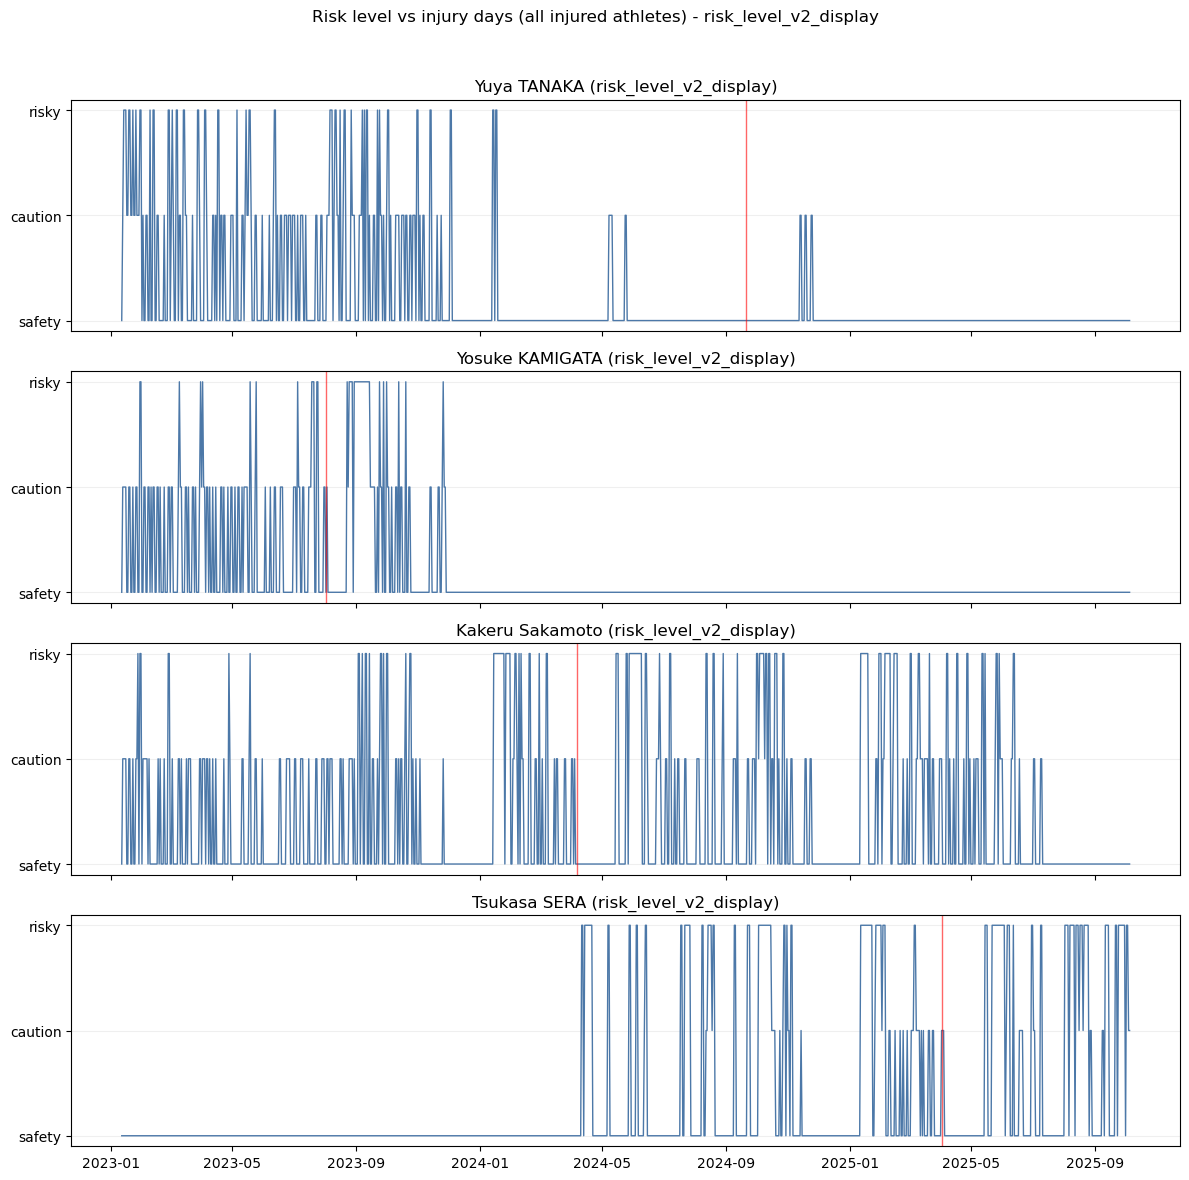

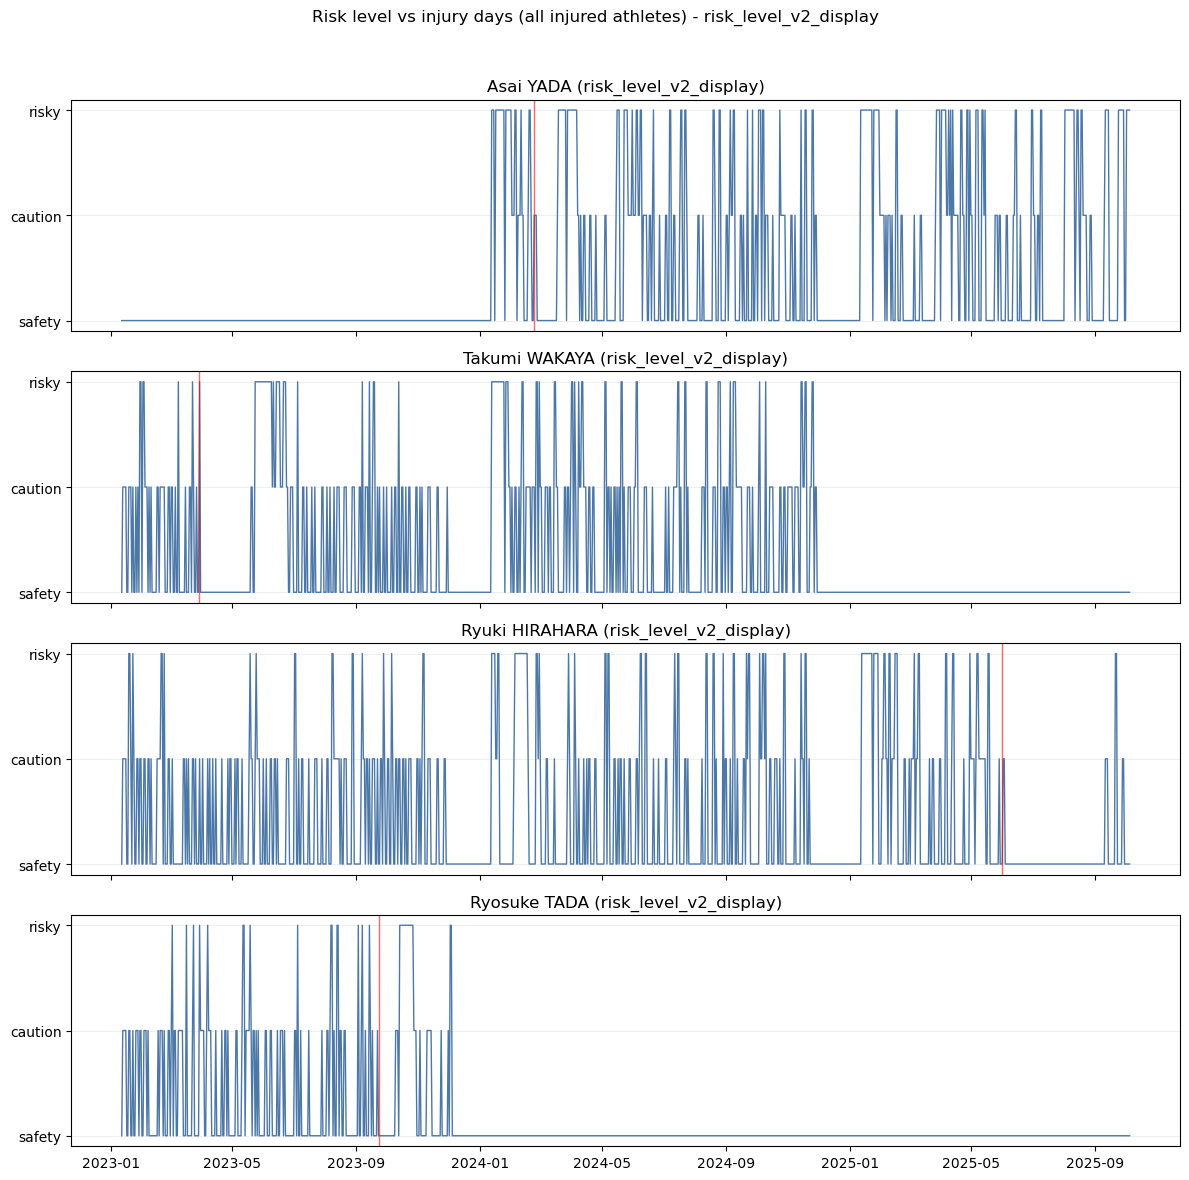

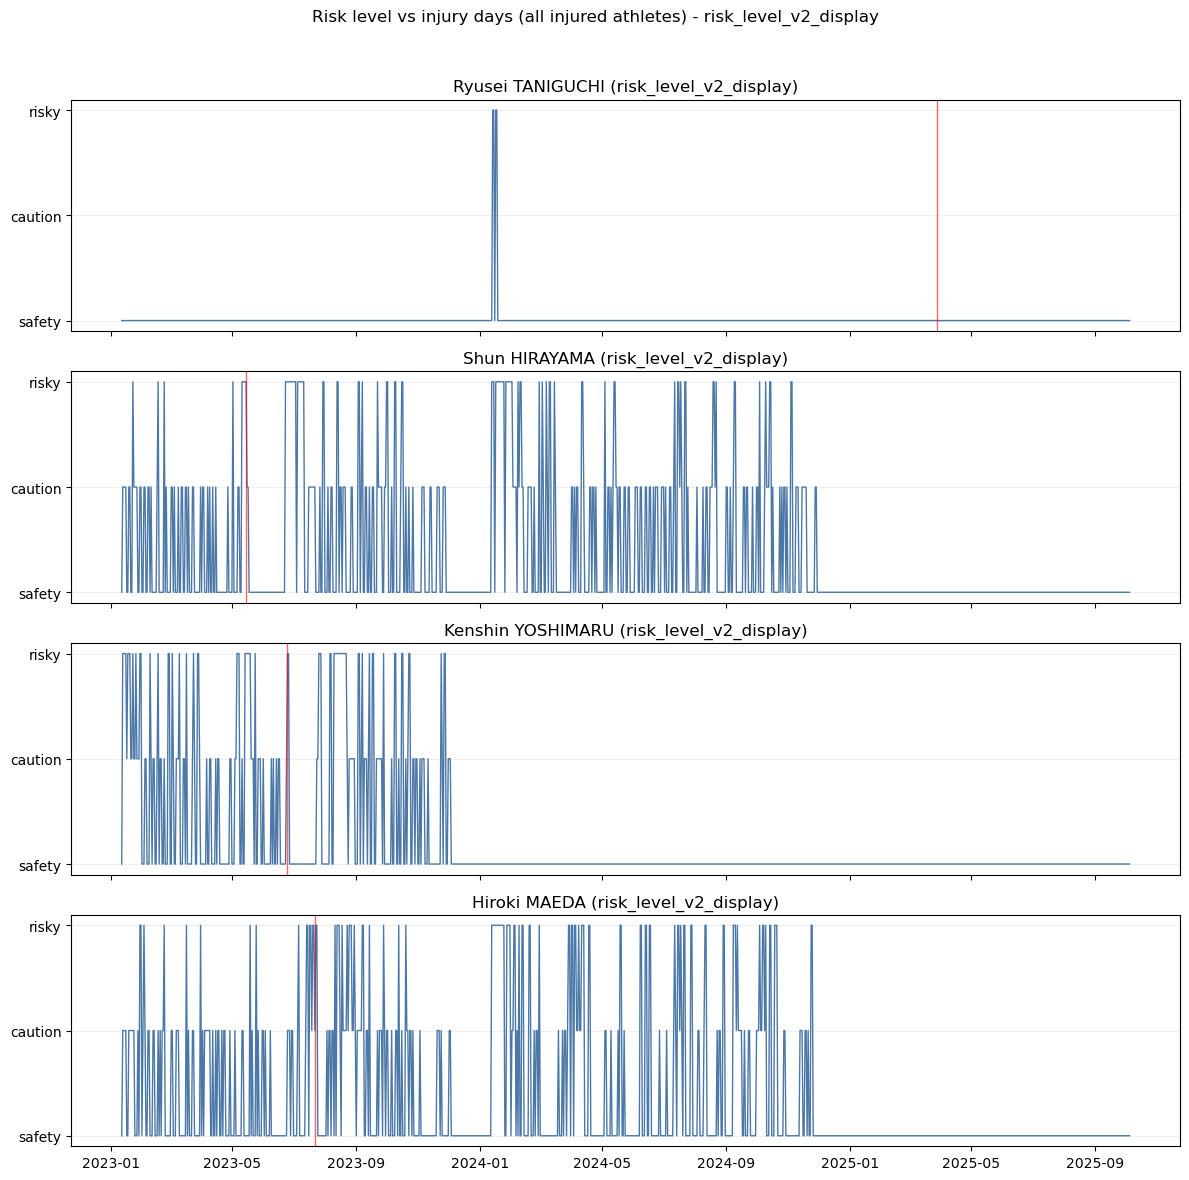

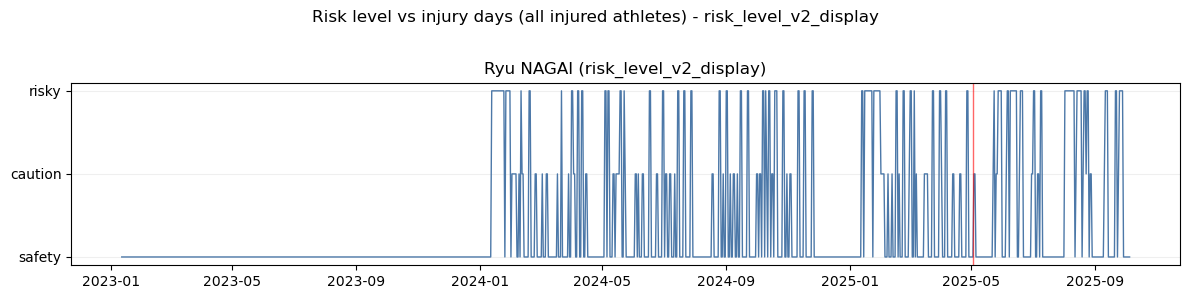

In [14]:
# --- Plot injury days vs risk level (all injured athletes) ---
import matplotlib.pyplot as plt

RISK_MAP = {"safety": 0, "caution": 1, "risky": 2}

def plot_injury_vs_risk(df: pd.DataFrame, athlete_name: str, ax=None, risk_col: str = "risk_level_v2_display"):
    data = df.copy()
    data = data[data["athlete_name"].str.upper() == athlete_name.upper()]
    data = data.sort_values("date")
    data = data[data["date"].notna()]
    data["risk_score"] = data[risk_col].map(RISK_MAP).fillna(0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(data["date"], data["risk_score"], color="#4c78a8", linewidth=1)

    injury_dates = data.loc[data["injury_event"] == 1, "date"]
    for i, dt in enumerate(injury_dates):
        ax.axvline(dt, color="red", alpha=0.6, linewidth=1)

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["safety", "caution", "risky"])
    ax.set_title(f"{athlete_name} ({risk_col})")
    ax.grid(True, axis="y", alpha=0.2)
    return ax

def plot_injury_vs_risk_all(df: pd.DataFrame, per_fig: int = 4, risk_col: str = "risk_level_v2_display"):
    injured_names = (
        df.loc[df["injury_event"] == 1, "athlete_name"]
        .dropna()
        .unique()
        .tolist()
    )
    if not injured_names:
        raise ValueError("No injury_event rows found.")

    for i in range(0, len(injured_names), per_fig):
        chunk = injured_names[i:i+per_fig]
        fig, axes = plt.subplots(len(chunk), 1, figsize=(12, 3 * len(chunk)), sharex=True)
        if len(chunk) == 1:
            axes = [axes]
        for ax, name in zip(axes, chunk):
            plot_injury_vs_risk(df, name, ax=ax, risk_col=risk_col)
        fig.suptitle(f"Risk level vs injury days (all injured athletes) - {risk_col}")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# run for all injured athletes (default: risk_level_v2_display)
plot_injury_vs_risk_all(features_df, per_fig=4, risk_col="risk_level_v2_display")
# to compare with backend rule: risk_col="risk_level"
